# 04 — Fair Value Gap (FVG) Validation

## Purpose
Add FVG confirmation to OB signals and measure its impact.

## Concept
A Fair Value Gap is a 3-candle imbalance:
- **Bullish FVG**: `candle[i].high < candle[i+2].low` → unfilled gap pointing up
- **Bearish FVG**: `candle[i].low > candle[i+2].high` → unfilled gap pointing down

FVG = evidence that price moved SO FAST it skipped a price range.
This is the fingerprint of institutional execution.

## Hypothesis
OB signals where the displacement left a FVG should have:
- Higher win rate (more institutional conviction behind the move)
- Fewer false retests (the FVG acts as an additional confluence zone)

## What we compare
- Baseline (no FVG filter) vs FVG-required
- Does requiring FVG hurt trade frequency more than it helps quality?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals
from strategy.confirmations.fvg import detect_fvgs, FVGType

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (16, 6)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = m5.sort_index()

print(f'Loaded {len(m5):,} M5 bars')

Loaded 19,798 M5 bars


In [2]:
# ── Step 1: Detect all FVGs in the M5 data ─────────────────────────────────
from strategy.ob_core import add_candle_features
m5_feat = add_candle_features(m5)

fvgs = detect_fvgs(m5_feat)
bull_fvgs = [f for f in fvgs if f.fvg_type == FVGType.BULLISH]
bear_fvgs = [f for f in fvgs if f.fvg_type == FVGType.BEARISH]

print(f'Total FVGs detected: {len(fvgs)}')
print(f'  Bullish: {len(bull_fvgs)}')
print(f'  Bearish: {len(bear_fvgs)}')

# FVG size distribution
fvg_sizes = [f.gap_size for f in fvgs]
print(f'\nFVG size stats (USD):')
print(f'  Mean  : {np.mean(fvg_sizes):.3f}')
print(f'  Median: {np.median(fvg_sizes):.3f}')
print(f'  Max   : {np.max(fvg_sizes):.3f}')

Total FVGs detected: 6332
  Bullish: 3157
  Bearish: 3175

FVG size stats (USD):
  Mean  : 1.934
  Median: 0.950
  Max   : 96.940


In [3]:
# ── Step 2: Compare OB signals with and without FVG requirement ─────────────

# Baseline: no FVG requirement
cfg_baseline = OBSignalConfig(rr=2.0)
sigs_baseline = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_baseline)

# FVG required
cfg_fvg = OBSignalConfig(rr=2.0, require_fvg=True, fvg_search_bars=8)
sigs_fvg = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_fvg)
sigs_fvg_passed = get_passed_signals(sigs_fvg)

print(f'Baseline signals : {len(sigs_baseline)}')
print(f'FVG signals total: {len(sigs_fvg)}')
print(f'FVG signals passed filter: {len(sigs_fvg_passed)}')
print(f'Filter rate: {(1 - len(sigs_fvg_passed)/max(len(sigs_baseline),1))*100:.1f}% of signals removed')

Baseline signals : 290
FVG signals total: 290
FVG signals passed filter: 199
Filter rate: 31.4% of signals removed


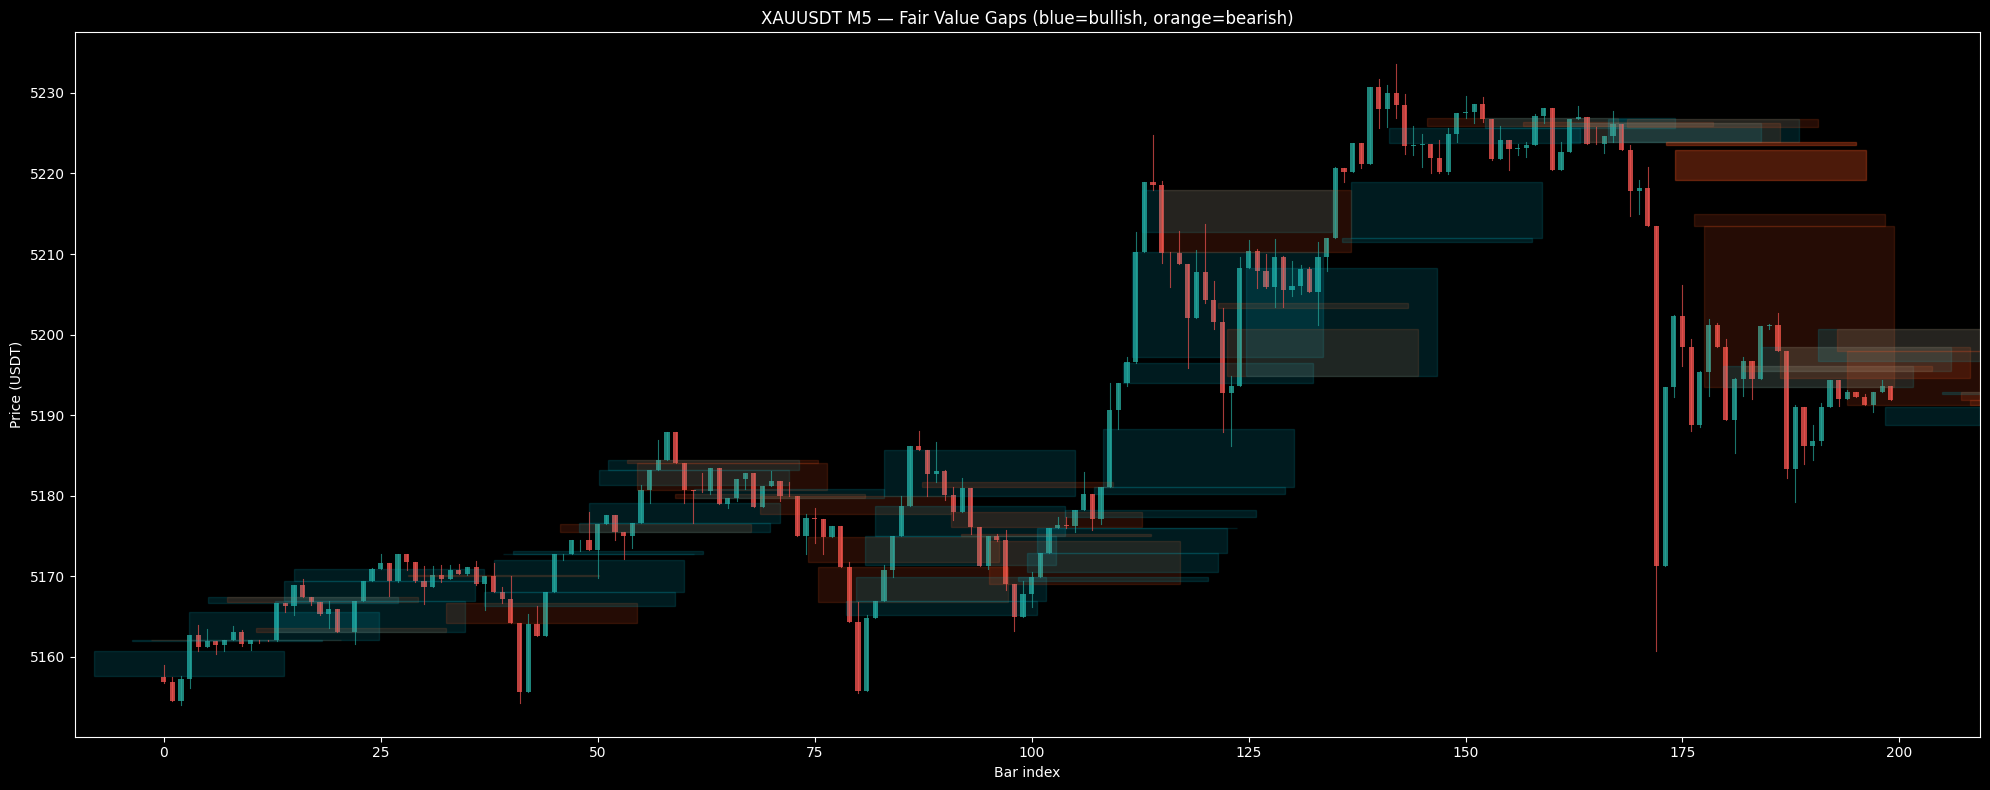

FVGs shown in chart section: 76


In [4]:
# ── Step 3: FVG visualization ───────────────────────────────────────────────
# Show FVGs on a section of price chart
start, end = 300, 500
chart_m5 = m5_feat.iloc[start:end]
chart_fvgs = [f for f in fvgs if start <= f.bar_idx < end]

fig, ax = plt.subplots(figsize=(20, 8))

# Price bars
for i, (ts, row) in enumerate(chart_m5.iterrows()):
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=0.8, alpha=0.7)
    h = abs(row['close'] - row['open'])
    ax.bar(i, h, bottom=min(row['open'], row['close']), color=color, width=0.6, alpha=0.8)

# FVG zones
for fvg in chart_fvgs:
    local_idx = fvg.bar_idx - start
    color = '#00BCD4' if fvg.fvg_type == FVGType.BULLISH else '#FF5722'
    alpha = 0.15 if fvg.filled else 0.30
    ax.axhspan(fvg.gap_low, fvg.gap_high, xmin=local_idx/len(chart_m5),
               xmax=min((local_idx+20)/len(chart_m5), 1.0),
               color=color, alpha=alpha,
               label=f"{fvg.fvg_type.value} FVG")

ax.set_title(f'{SYMBOL} M5 — Fair Value Gaps (blue=bullish, orange=bearish)')
ax.set_xlabel('Bar index')
ax.set_ylabel('Price (USDT)')
plt.tight_layout()
plt.show()

print(f'FVGs shown in chart section: {len(chart_fvgs)}')

In [5]:
# ── Step 4: Impact analysis ─────────────────────────────────────────────────
print('=== FVG FILTER IMPACT ===')
print(f'Signals removed : {len(sigs_baseline) - len(sigs_fvg_passed)}')
print(f'Signal reduction: {(1 - len(sigs_fvg_passed)/max(len(sigs_baseline),1))*100:.1f}%')
print()
print('To quantify QUALITY impact, run notebook 12 (full comparison).')
print('Next step: notebook 05 will add BOS/MSS and measure combined effect.')

=== FVG FILTER IMPACT ===
Signals removed : 91
Signal reduction: 31.4%

To quantify QUALITY impact, run notebook 12 (full comparison).
Next step: notebook 05 will add BOS/MSS and measure combined effect.
